In [9]:
#Load Mosaics

from pathlib import Path
from preprocessing import load_data
import matplotlib.pyplot as plt
import numpy as np

data_dir = Path("../data")

img_mosaic, mask_mosaic, transform, crs = load_data(data_dir)

In [10]:
# Extract RGB (R, G, B order for plotting)
red = img_mosaic[2]
green = img_mosaic[1]
blue = img_mosaic[0]

In [11]:
#Stack rgb
rgb = np.stack([red, green, blue], axis=-1)

In [12]:
#Normalize to display

def normalize(img):
    img = img.astype(np.float32)
    img_min = np.percentile(img, 2)
    img_max = np.percentile(img, 98)
    img = (img - img_min) / (img_max - img_min)
    return np.clip(img, 0, 1)

rgb_norm = normalize(rgb)

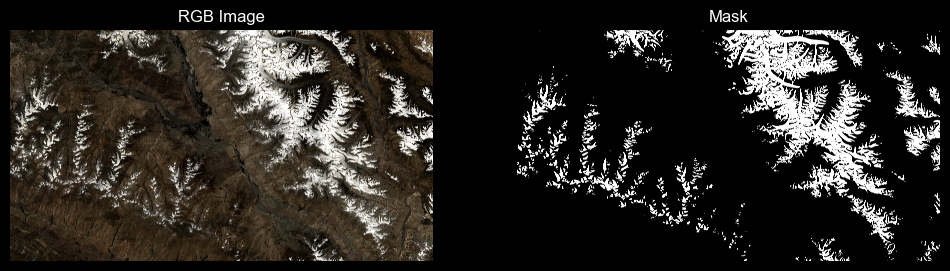

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_norm)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_mosaic[0], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.savefig('AOI.png', transparent=True)
plt.show()

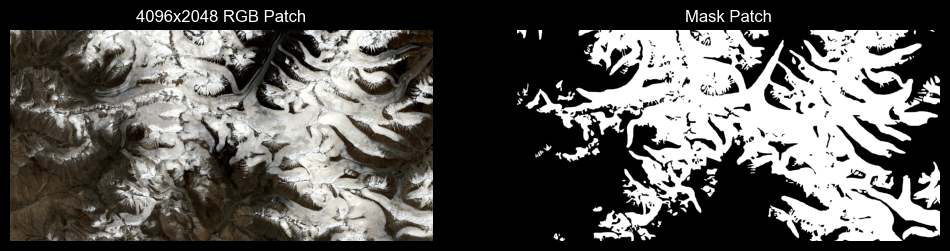

In [14]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import load_data

# Load full mosaic
data_dir = Path("../data")
img_mosaic, mask_mosaic, _, _ = load_data(data_dir)

# ---- Choose the glacier patch ----
y, x = 3072, 9216   # change this to move around

PATCH_SIZE_y = 2048
PATCH_SIZE_x = 4096

# Extract patch
img_patch = img_mosaic[:, y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x]
mask_patch = mask_mosaic[:, y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x]

# ---- Extract RGB ----
red = img_patch[2]
green = img_patch[1]
blue = img_patch[0]

rgb = np.stack([red, green, blue], axis=-1)

# Normalize and show
def normalize(img):
    p2, p98 = np.percentile(img, (2, 98))
    img = (img - p2) / (p98 - p2)
    return np.clip(img, 0, 1)

rgb_norm = normalize(rgb)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_norm)
plt.title("4096x2048 RGB Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_patch[0], cmap="gray")
plt.title("Mask Patch")
plt.axis("off")


plt.show()



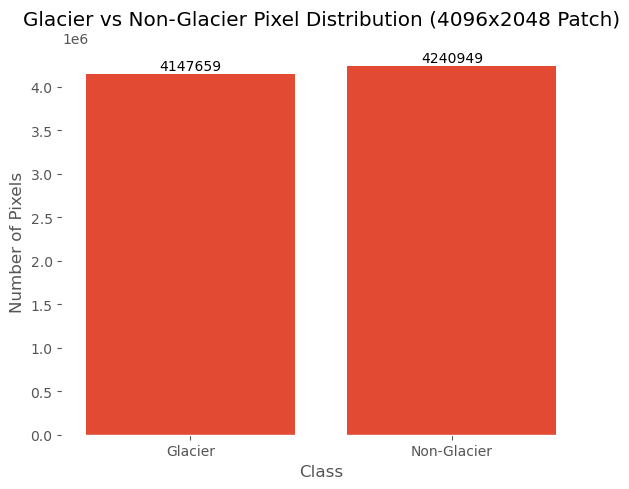

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Glacier = 1, Non-glacier = 0

# Count pixels
glacier_pixels = np.sum(mask_patch == 1)
non_glacier_pixels = np.sum(mask_patch == 0)

# Store values
labels = ['Glacier', 'Non-Glacier']
values = [glacier_pixels, non_glacier_pixels]

# Plot
plt.figure(figsize=(6, 5), facecolor='white')
plt.bar(labels, values)

# Add value labels on top
for i, v in enumerate(values):
    plt.text(i, v + (0.01 * max(values)), str(v), ha='center')

plt.title('Glacier vs Non-Glacier Pixel Distribution (4096x2048 Patch)')
plt.ylabel('Number of Pixels')
plt.xlabel('Class')

plt.gca().set_facecolor('white')

plt.tight_layout()
plt.show()

In [7]:
# Get DEM
dem = img_mosaic[6]

In [8]:
# Compute Terrain Features:
from preprocessing import compute_terrain_features

terrain_features = compute_terrain_features(dem, transform, crs)

In [9]:
img_patch = img_mosaic[:, y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x]

terrain_patch = np.stack([
    t[y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x] for t in terrain_features
])

In [10]:
# Combine:
full_patch = np.concatenate([img_patch, terrain_patch], axis=0)
print(full_patch.shape)

(18, 2048, 4096)


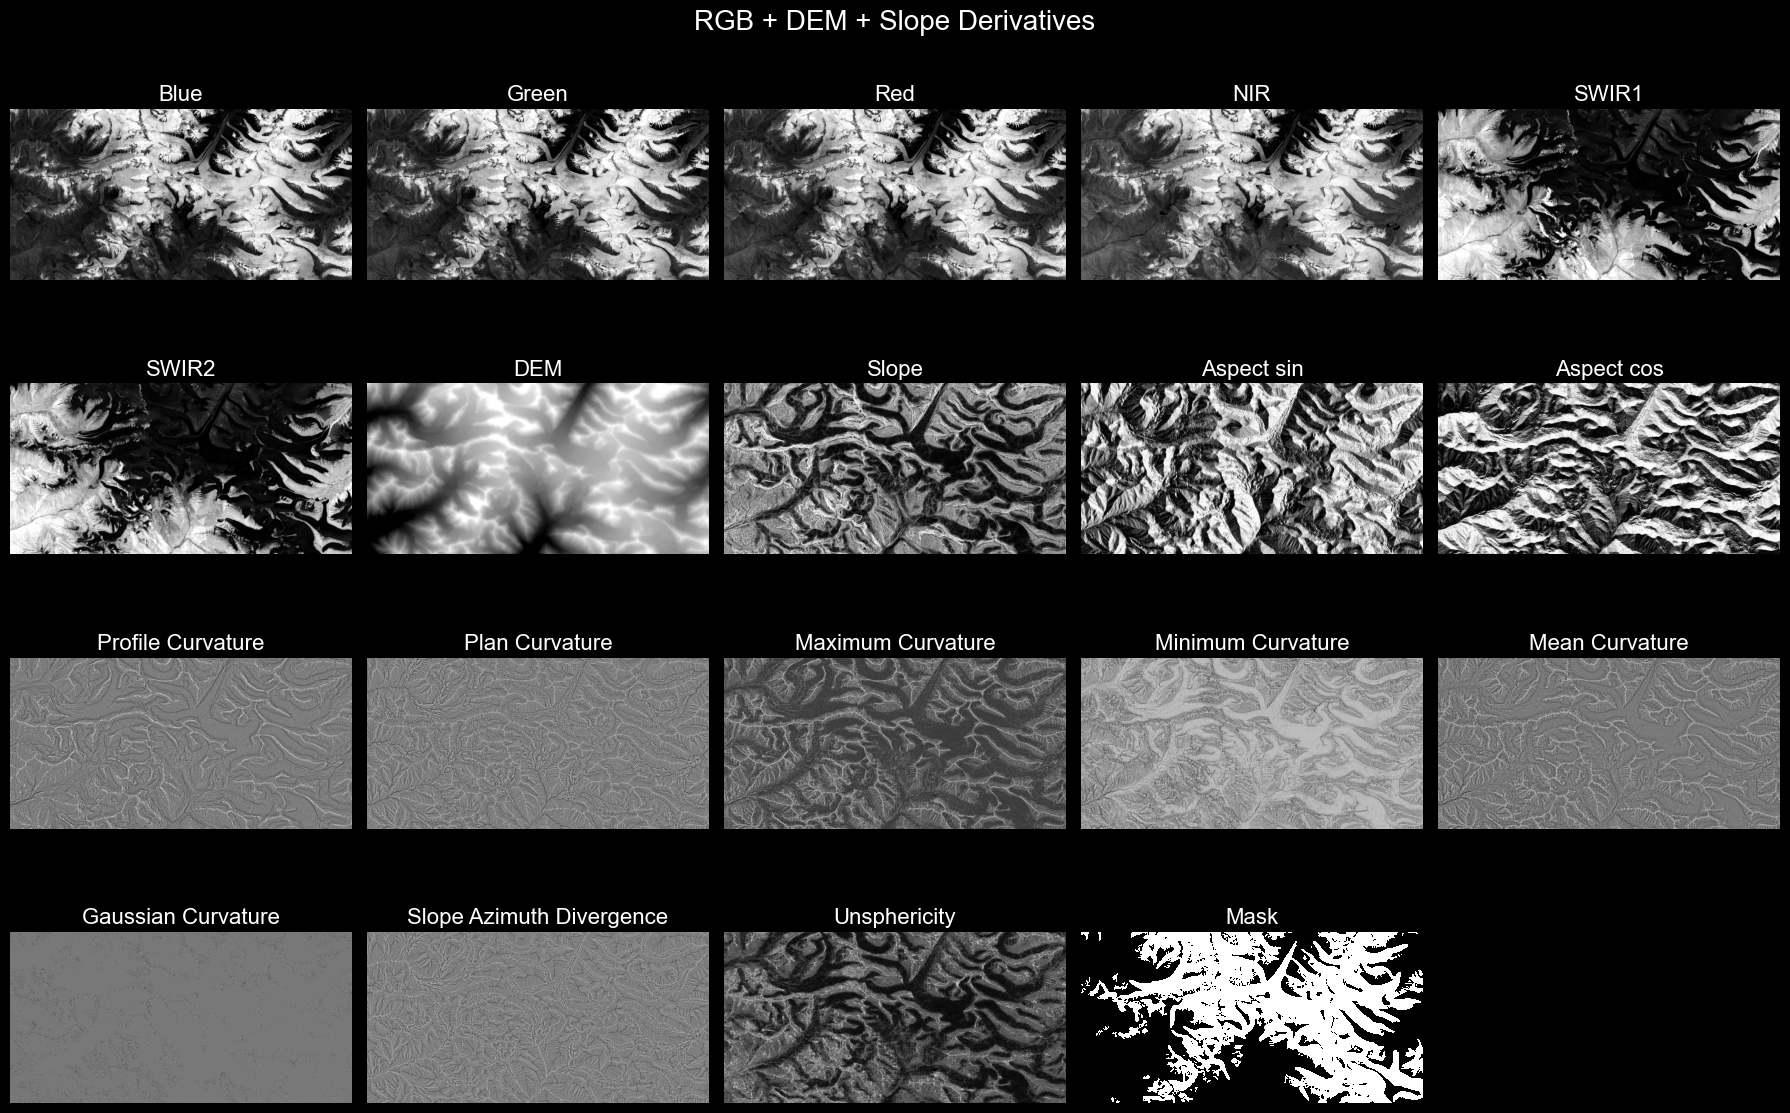

In [11]:
# Plot each band
import matplotlib.pyplot as plt

num_bands = full_patch.shape[0]

plt.figure(figsize=(18, 12))

band_names = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "DEM",
    "Slope", "Aspect sin", "Aspect cos",
    "Profile Curvature", "Plan Curvature",
    "Maximum Curvature", "Minimum Curvature", "Mean Curvature",
    "Gaussian Curvature", "Slope Azimuth Divergence", "Unsphericity"
]

# ---- Plot all bands ----
for i in range(num_bands):
    plt.subplot(4, 5, i + 1)

    band = full_patch[i]

    # Normalize each band individually for visibility
    p2, p98 = np.percentile(band, (2, 98))
    band_norm = (band - p2) / (p98 - p2)
    band_norm = np.clip(band_norm, 0, 1)

    plt.imshow(band_norm, cmap="gray")
    plt.title(band_names[i], fontsize=16)
    plt.axis("off")

# ---- Plot mask ----
plt.subplot(4, 5, num_bands + 1)
plt.imshow(mask_patch[0], cmap="gray", interpolation='nearest', vmin=0, vmax=1)
plt.title("Mask", fontsize=16)
plt.axis("off")

plt.suptitle("RGB + DEM + Slope Derivatives", fontsize=20)
plt.subplots_adjust(wspace=0.02, hspace=0)
plt.tight_layout()
plt.show()